# Preprocessing of time dependent data

Time series data is a collection of quantities that are assembled over even intervals in time and ordered chronologically. The time interval at which data is collection is generally referred to as the time series frequency. Interesting questions are: 

* Are there seasonality pattern? For example in the time series of the temperature? 

* Does the data show some trends such that we could make assumptions about the future? 

* How do we deal with missing data?

We begin this chapter with loading the meteorological data set from the DWD. 

In [75]:
import pandas as pd

#Read the data set:
df = pd.read_csv("Tagesmittel_Dahlem.csv", sep = ';')

#Name the columns:
df.columns = ['STAT','Date', 'QN', 'TG', 'TN', 'TM', 'TX', 'RFM', 'FM', 'FX', 'SO', 'NM', 'RR', 'PM']

#Drop columns we want to ignore:
df = df.drop(columns=['STAT','QN','PM'])

**Data**: Description of the Variables:
    
- **QN** Quality of the data <br>
- **TG** Minimum of the temperature 5 cm over the earth surface, Grad C TIII of the day before until  TI 23:51 day before - 23:50 UTC <br>
- **TN** Minimum of the temperature 2 m over the earth surface, Grad C TIII of the day before until TIII 23:51 day before - 23:50 UTC <br>
- **TM** Arithmetic mean of the temperature in 2 m over the earth surface, Grad C (TI+TII+2*TIII) / 4, mean of 24 values <br>
- **TX** Maximum of the temperature in 2 m over the earth surface, Grad C TIII of the day before until  TIII 23:51 day before - 23:50 UTC <br>
- **RFM** Arithmetic mean of the realative moisture % (TI+TII+TIII)/3, mean of 24 values <br>
- **FM** Arithmetic mean of the wind speed in Bft (TI+TII+TIII)/3, mean of 24 values <br>
- **FX** Maximum der Wind speed (Spitzenböe) m/sec 00 – 23:59 UTC 23:51 day before - 23:50 UTC <br>
- **SO** Sum of the sun duration, hours 00 – 23:59 UTC 23:51 day before - 23:50 UTC <br>
- **NM** Arithmetic mean of cloud amount (Bedeckungsgrad), eighth (TI+TII+TIII)/3 mean of 24 values <br>
- **RR** Precipitation intensity in mm TI until TI of the day after, 05:51 - 05:50 UTC of the day after <br>
- **PM** Artithmetic mean of the air pressure at station hight hpa (TI+TII+TIII)/3 mean of 24 values. 

In general, the following applies to the calculation of daily mean values:

As of April 1st, 2001, the standard was changed as follows:
The daily mean is calculated from 24 hourly values.
If more than 3 hourly values are missing, the calculation is based on the 4 main observation times (00, 06, 12, 18 UTC).
The reference period for one day usually runs from 23:51 UTC of the previous day to 23:50 UTC.

Only the precipitation of the previous day is measured in the morning at 05:50 UTC.
The observation times are related to the globally used time in Greenwich (GMT or UTC).
The observation time is always 10 minutes before the reference time (hence the “uneven” time indications).
This adjustment became necessary after the station network was largely automated.


In [76]:
df

,Date,TG,TN,TM,TX,RFM,FM,FX,SO,NM,RR
0,20200325,-7.3,-2.6,3.9,11.0,41.0,3.0,11.5,11.8,0.5,0.0
1,20200324,-8.3,-4.8,2.1,8.7,46.5,3.0,10.3,11.9,0.7,0.0
2,20200323,-8.2,-4.4,0.8,6.7,52.5,2.0,8.1,11.8,0.2,0.0
3,20200322,-7.1,-2.5,1.8,6.5,55.3,3.0,11.0,11.8,0.4,0.0
4,20200321,-4.5,0.2,4.1,7.4,64.8,4.0,13.6,8.0,2.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...
494,20181117,-5.5,-2.5,1.5,5.5,84.7,3.0,9.4,7.8,1.3,0.0
495,20181116,-1.6,1.6,5.0,9.3,79.9,3.0,11.5,8.2,2.3,0.0
496,20181115,1.1,4.2,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0
497,20181114,1.2,4.7,7.2,11.0,96.1,2.0,8.8,6.4,5.0,0.0


Let us have a look on the distributions of the data

/Users/annetterudolph/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


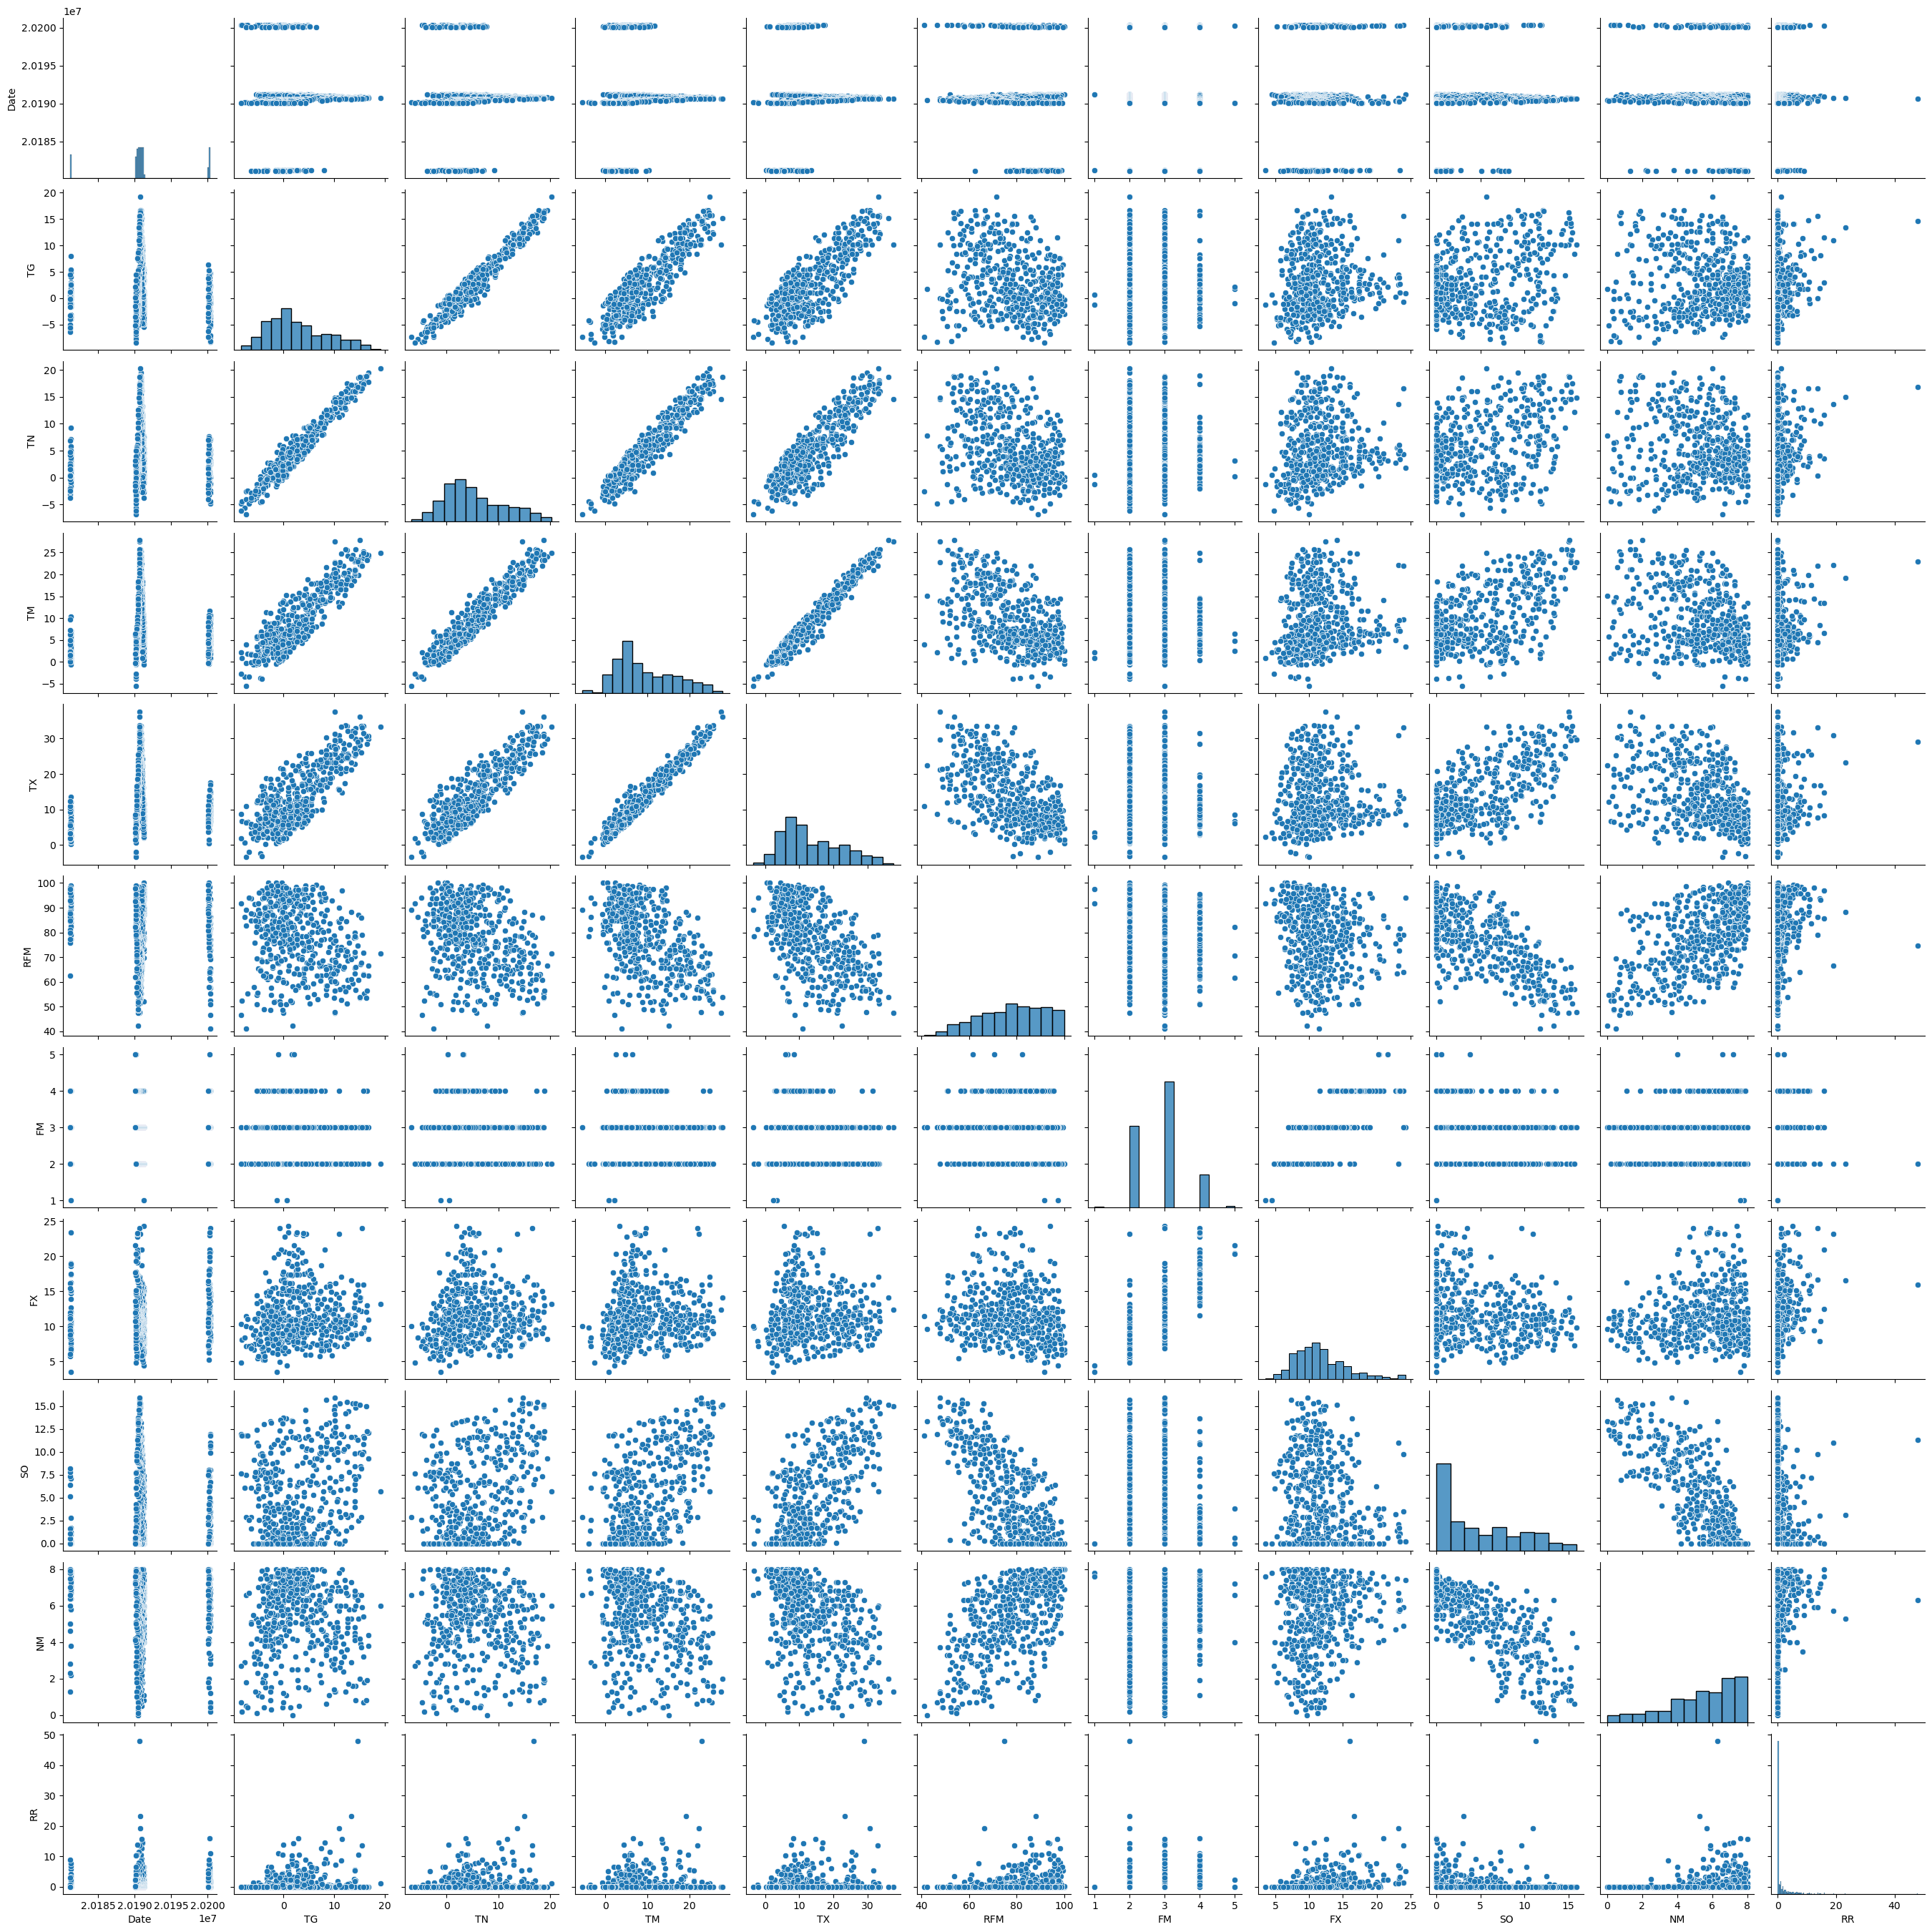

In [77]:
import seaborn as sns
sns.pairplot(df)

If we aim to analyze this dataset and build, for example, a machine learning model, we would have to transform all the data.
For simplicity, we will focus on the minimum and maximum temperatures, drop all other features, and look again at the distribution of the minimum and maximum temperature.

In [78]:
df = df.drop(columns=['TG','TM', 'RFM', 'FM', 'FX', 'SO', 'NM'])

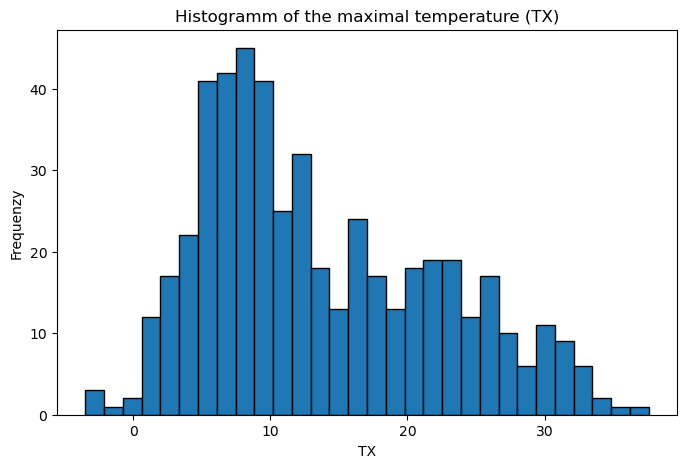

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
n, bins, patches = plt.hist(df['TX'], bins=30, edgecolor='black')
plt.xlabel('TX')
plt.ylabel('Frequenzy')
plt.title('Histogramm of the maximal temperature (TX)')
plt.show()

Oh, the distribution does not look symmetric at all. Therefore, we will scale the data between zero and one in the first step. For the **min-max transformation**, we use *max − 1* instead of *max* and *min + 1* instead of *min*, because we want the data to lie within the open interval between zero and one. This means that zero and one are not part of the transformed dataset.

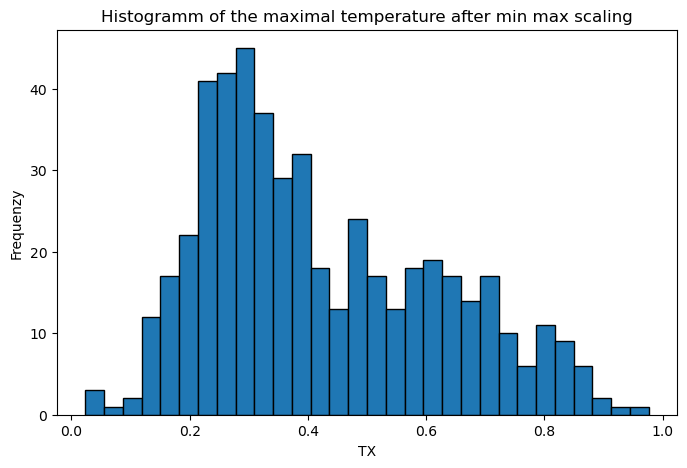

In [80]:
# Step 1: Min Max Scaling and check the distribution

tx = df['TX']
tx_minmax = (tx - tx.min()+1) / (tx.max() - tx.min()+2)

plt.figure(figsize=(8,5))

n, bins, patches = plt.hist(tx_minmax, bins=30, edgecolor='black')
plt.xlabel('TX')
plt.ylabel('Frequenzy')
plt.title('Histogramm of the maximal temperature after min max scaling')
plt.show()

As we can see, the data now lie in the open interval ]0,1[. However, this step did not change the distribution. To obtain a more symmetric distribution and, ultimately, a dataset defined over the entire real space, we next apply a log transformation.


In [81]:
import numpy as np 

tx_minmax_log = np.log(tx_minmax/(1-tx_minmax))



Let us check the distribution of the log transformed data:

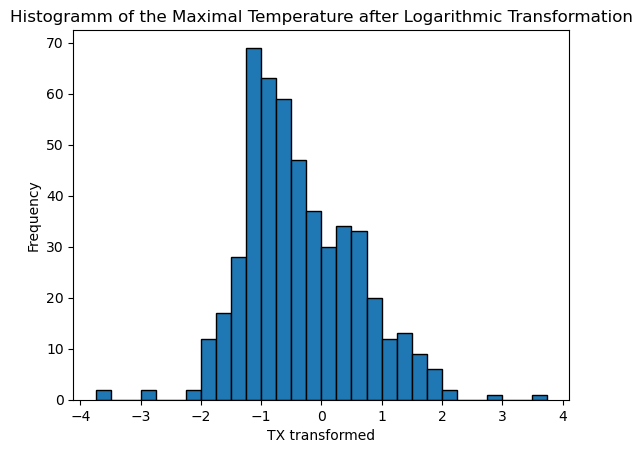

In [82]:
n, bins, patches = plt.hist(tx_minmax_log, bins=30, edgecolor='black')
plt.xlabel('TX transformed')
plt.ylabel('Frequency')
plt.title('Histogramm of the Maximal Temperature after Logarithmic Transformation')
plt.show()

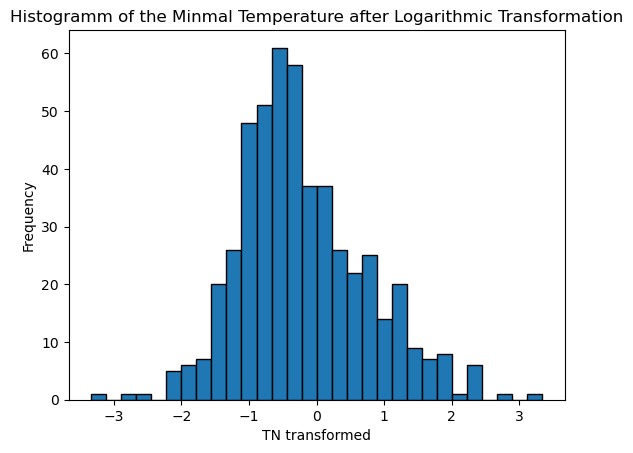

In [83]:
tn = df['TN']
tn_minmax = (tn - tn.min()+1) / (tn.max() - tn.min()+2)
tn_minmax_log = np.log(tn_minmax/(1-tn_minmax))

n, bins, patches = plt.hist(tn_minmax_log, bins=30, edgecolor='black')
plt.xlabel('TN transformed')
plt.ylabel('Frequency')
plt.title('Histogramm of the Minmal Temperature after Logarithmic Transformation')
plt.show()

OK, that looks much more symmetric than the original data set. Let us add the transformed data to our dataframe.

In [84]:
df['TX transformed'] = tx_minmax_log
df['TN transformed'] = tx_minmax_log

##### Sort the data set by date: 2018...2020

In [85]:
df = df.sort_values(by=['Date'], ascending = True)
df

,Date,TN,TX,RR,TX transformed,TN transformed
498,20181113,6.8,12.3,8.9,-0.448190,-0.448190
497,20181114,4.7,11.0,0.0,-0.576976,-0.576976
496,20181115,4.2,10.4,0.0,-0.637961,-0.637961
495,20181116,1.6,9.3,0.0,-0.752919,-0.752919
494,20181117,-2.5,5.5,0.0,-1.196948,-1.196948
...,...,...,...,...,...,...
4,20200321,0.2,7.4,0.0,-0.963880,-0.963880
3,20200322,-2.5,6.5,0.0,-1.070961,-1.070961
2,20200323,-4.4,6.7,0.0,-1.046692,-1.046692
1,20200324,-4.8,8.7,0.0,-0.817642,-0.817642


What is the data type of the values in the date column?

In [86]:
df['Date']

498    20181113
497    20181114
496    20181115
495    20181116
494    20181117
         ...   
4      20200321
3      20200322
2      20200323
1      20200324
0      20200325
Name: Date, Length: 499, dtype: int64

The data type is integer (int64), but we would like to transform these numbers into dates:

## Python's Datetime

##### Transform integers to dates:

In [56]:
from datetime import datetime

df['Datum'] = pd.to_datetime(df['Date'],format='%Y%m%d')
df.head()

,Date,TN,TX,RR,TX transformed,TN transformed,Datum
498,20181113,6.8,12.3,8.9,-0.448190,-0.448190,2018-11-13
497,20181114,4.7,11.0,0.0,-0.576976,-0.576976,2018-11-14
496,20181115,4.2,10.4,0.0,-0.637961,-0.637961,2018-11-15
495,20181116,1.6,9.3,0.0,-0.752919,-0.752919,2018-11-16
494,20181117,-2.5,5.5,0.0,-1.196948,-1.196948,2018-11-17


In [57]:
df['Datum']

498   2018-11-13
497   2018-11-14
496   2018-11-15
495   2018-11-16
494   2018-11-17
         ...    
4     2020-03-21
3     2020-03-22
2     2020-03-23
1     2020-03-24
0     2020-03-25
Name: Datum, Length: 499, dtype: datetime64[ns]

Well down! The type is now datatime! Now we would like the dates to be our indices instead of the numbers. 

##### Set the date as Index: 

First, delete the 'Data' - column. Second, set the 'Datum' columns as index: 

In [58]:
#Drop columns we want to ignore:
df = df.drop(columns=['Date'])

#set the 'Datum' columns as index: 
df = df.set_index('Datum')

In [59]:
df

,TN,TX,RR,TX transformed,TN transformed
Datum,,,,,
2018-11-13,6.8,12.3,8.9,-0.448190,-0.448190
2018-11-14,4.7,11.0,0.0,-0.576976,-0.576976
2018-11-15,4.2,10.4,0.0,-0.637961,-0.637961
2018-11-16,1.6,9.3,0.0,-0.752919,-0.752919
2018-11-17,-2.5,5.5,0.0,-1.196948,-1.196948
...,...,...,...,...,...
2020-03-21,0.2,7.4,0.0,-0.963880,-0.963880
2020-03-22,-2.5,6.5,0.0,-1.070961,-1.070961
2020-03-23,-4.4,6.7,0.0,-1.046692,-1.046692


## Benefits of the DatetimeIndex


##### 1. Subsetting and slicing

A very common task in time series analysis is the subsetting of a time series.

Mybe you are interested in the oldest or newest observations, or you would like to extract a certain range of data:

Since we have set the data as index, we can easily look at the data of a certain time: 

In [60]:
df.loc['2018-11-13']

TN                 6.80000
TX                12.30000
RR                 8.90000
TX transformed    -0.44819
TN transformed    -0.44819
Name: 2018-11-13 00:00:00, dtype: float64

Or we can have a look at the data of a certain time interval: 

How was the weather last June?

In [61]:
df_June = df['2019-06-01':'2019-06-30']
df_June

,TN,TX,RR,TX transformed,TN transformed
Datum,,,,,
2019-06-01,14.0,27.1,0.0,1.010810,1.010810
2019-06-02,14.6,31.3,0.0,1.590074,1.590074
2019-06-03,15.6,33.2,0.0,1.943261,1.943261
2019-06-04,17.2,30.6,0.0,1.478760,1.478760
2019-06-05,16.0,33.6,0.0,2.030776,2.030776
2019-06-06,14.5,31.7,5.4,1.657538,1.657538
2019-06-07,12.8,25.7,0.1,0.850615,0.850615
2019-06-08,10.4,22.6,0.0,0.526945,0.526945
2019-06-09,8.7,25.9,3.4,0.872841,0.872841


Another nice feature using Python and Python's datetime is to generate a new time series. 
We can define a starting date `start="6/1/2019`and a end date `end="6/30/2020`of the series. 

Moreover, we can define a frequency, for example daily, 'D', hourly ('H'), calendar daily ('D'), business daily ('B'), weekly ('W'), monthly ('M'), quarterly ('Q'), annual ('A'), and many others. Frequencies can also be specified as multiples of any of the base frequencies, for example '5D' for every five days. There are many more...

For example:

In [62]:
New_series = pd.date_range(start="6/1/2019",end="6/1/2020",freq='B')
New_series

DatetimeIndex(['2019-06-03', '2019-06-04', '2019-06-05', '2019-06-06',
               '2019-06-07', '2019-06-10', '2019-06-11', '2019-06-12',
               '2019-06-13', '2019-06-14',
               ...
               '2020-05-19', '2020-05-20', '2020-05-21', '2020-05-22',
               '2020-05-25', '2020-05-26', '2020-05-27', '2020-05-28',
               '2020-05-29', '2020-06-01'],
              dtype='datetime64[ns]', length=261, freq='B')

or: 

In [63]:
daily_index = pd.date_range(start="4/1/2018",end="4/30/2018",freq='D')
daily_index

DatetimeIndex(['2018-04-01', '2018-04-02', '2018-04-03', '2018-04-04',
               '2018-04-05', '2018-04-06', '2018-04-07', '2018-04-08',
               '2018-04-09', '2018-04-10', '2018-04-11', '2018-04-12',
               '2018-04-13', '2018-04-14', '2018-04-15', '2018-04-16',
               '2018-04-17', '2018-04-18', '2018-04-19', '2018-04-20',
               '2018-04-21', '2018-04-22', '2018-04-23', '2018-04-24',
               '2018-04-25', '2018-04-26', '2018-04-27', '2018-04-28',
               '2018-04-29', '2018-04-30'],
              dtype='datetime64[ns]', freq='D')

***

##### 2. Benefit: Easy plotting

We take again a look at the DWD-data to see one major benefit of the DatetimeIndex.

Plot the whole data set


<Axes: xlabel='Datum'>

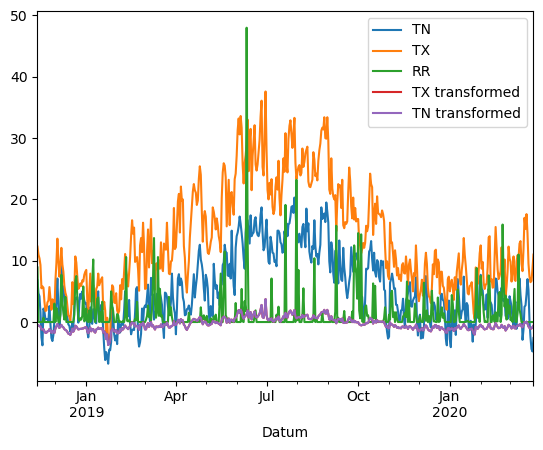

In [64]:
import matplotlib.pyplot as plt

df.plot()

Or a variable that you yould like to analyize, for exmaple the mean temperature:

<Axes: title={'center': 'Maximal temperature (TX)'}, xlabel='Date', ylabel='Temperature in °C'>

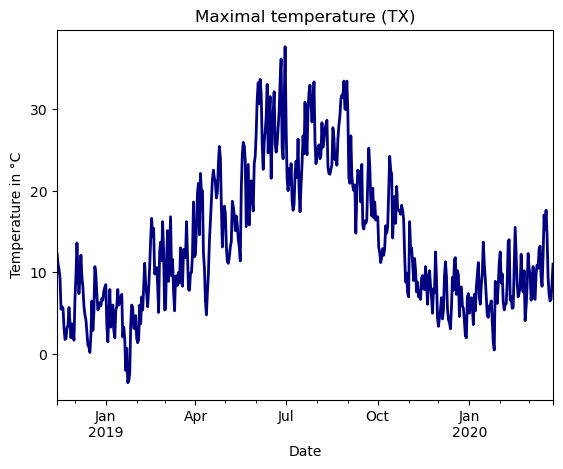

In [65]:
df['TX'].plot(lw=2, colormap='jet', ylabel='Temperature in °C',xlabel='Date',
         title='Maximal temperature (TX)')

>**Exercise 1** <br>
> Was the sun shining in summer 2019? Plot the Sonnenscheindauer 'SO' (or another variable) from the DWD data set for the time slice Mai, Juni, July and August 2019



##  Summary statistics

Recall the basic functions for statistics using pandas: 

* Quantiles: `DataFrame.quantile(self, q=0.5, axis=0, numeric_only=True, interpolation='linear')` 

* Median: `DataFrame.median(self, axis=None, skipna=None, level=None, numeric_only=None, **kwargs)

* Arithmetic Mean: `DataFrame.mean(axis=None, skipna=None, level=None, numeric_only=None, **kwargs)`

* Geometric Mean: from scipy import stats `stats.gmean(dataframe)`

* Variance: `DataFrame.var(self, axis=None, skipna=None, level=None, ddof=1, numeric_only=None, **kwargs)`

* Standard deviation: `DataFrame.std(self, axis=None, skipna=None, level=None, ddof=1, numeric_only=None, **kwargs)`


To get a quick overview on the statistical characteristics of time series we can also use the describe() function. The function returns basic statistics for the whole data set.

In [66]:
df.describe()

,TN,TX,RR,TX transformed,TN transformed
count,499.000000,499.000000,499.000000,499.000000,499.000000
mean,5.308016,13.663327,1.424048,-0.351337,-0.351337
std,5.769047,8.509267,3.571932,0.942899,0.942899
min,-6.800000,-3.500000,0.000000,-3.740048,-3.740048
25%,0.950000,7.000000,0.000000,-1.010810,-1.010810
50%,4.100000,11.400000,0.000000,-0.536898,-0.536898
75%,9.400000,20.150000,1.200000,0.289714,0.289714
max,20.300000,37.600000,48.000000,3.740048,3.740048


In [67]:
df.describe().round(1)

,TN,TX,RR,TX transformed,TN transformed
count,499.0,499.0,499.0,499.0,499.0
mean,5.3,13.7,1.4,-0.4,-0.4
std,5.8,8.5,3.6,0.9,0.9
min,-6.8,-3.5,0.0,-3.7,-3.7
25%,1.0,7.0,0.0,-1.0,-1.0
50%,4.1,11.4,0.0,-0.5,-0.5
75%,9.4,20.2,1.2,0.3,0.3
max,20.3,37.6,48.0,3.7,3.7


In [70]:
# Save as csv file:
df.to_csv('./Temperature_Dahlem_transformed.csv', index=True, header=True)

> **Exercise** <br>
> 1. Plot the distribution of the precipitation (RR).<br>
> 2. Discuss: Consider the histogram and the statistics of the precipiation (RR). Does the standard deviation given by the describe function make sense?

The describe function can be applied to time slices, too! 

In [26]:
df["2019-01-01":"2020-01-1"].describe().round(1)

,TN,TX,RR,TX transformed,TN transformed
count,366.0,366.0,366.0,366.0,366.0
mean,6.5,15.8,1.4,-0.1,-0.1
std,6.1,8.8,3.8,1.0,1.0
min,-6.8,-3.5,0.0,-3.7,-3.7
25%,1.7,8.4,0.0,-0.8,-0.8
50%,6.0,15.6,0.0,-0.1,-0.1
75%,11.4,22.7,1.1,0.5,0.5
max,20.3,37.6,48.0,3.7,3.7


***

##  Generating DatetimeIndex with periods and frequency arguments

If we need to create a index with the dates of our data, we can do it with Python as follows: 

`pandas.date_range(start=None, end=None, periods=None, freq=None, tz=None, normalize=False, name=None, closed=None, **kwargs`  

Return a fixed frequency DatetimeIndex

Parameters: 

* start: str or datetime-like, optional, Left bound for generating dates.
* end: str or datetime-like, optional, Right bound for generating dates.
* periods: int, optional, Number of periods to generate.
* freq: str or DateOffset, default ‘D’
* Frequency strings can have multiples, e.g. ‘5H’. See here for a list of frequency aliases.
* tz: str or tzinfo, optional, Time zone name for returning localized DatetimeIndex, for example ‘Asia/Hong_Kong’. By default, the resulting DatetimeIndex is timezone-naive.
* normalize: bool, default False
* Normalize start/end dates to midnight before generating date range.
* namestr, default None, Name of the resulting DatetimeIndex.
*  closed{None, ‘left’, ‘right’}, optional, Make the interval closed with respect to the given frequency to the ‘left’, ‘right’, or both sides (None, the default).


The default input for the frequency is 'D' which stands for daily. But there are many more specifications for the frequency: 

* B business day frequency
* C custom business day frequency
* D calendar day frequency
* W weekly frequency
* M month end frequency
* Q quarter end frequency
* H hourly frequency
* T, min minutely frequency
* S secondly frequency

There are more... see: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-offset-aliases



***

## What to do with missing values (NaNs)?


Missing values in data sets are a well-known problem as nearly everywhere, where data is measured and recorded, issues with missing values occur. Missing values can lead to problems, because often further data processing and analysis steps rely on complete data sets. Therefore missing values need to be replaced with reasonable values. In statistics this process is called [**imputation**](https://en.wikipedia.org/wiki/Imputation_(statistics)).


***

### Imputation of univariate time series

Techniques capable of doing imputation for univariate time series can be roughly divided into three categories ([Moritz et al. 2015](https://arxiv.org/abs/1510.03924)):

* **Univariate algorithms** These algorithms work with univariate inputs, but typically do not employ the time series character of the data set. Examples are: *mean*, *mode*, *median*, *random sample*.

* **Univariate time series algorithms** These algorithms are also able to work with univariate inputs, but make use of the time series characteristics. Examples of simple algorithms of this category are *last observation carried forward (locf)*, *next observation carried backward (nocb)*, *arithmetic smoothing* and *linear interpolation*. The more advanced algorithms are based on structural time series models and can handle seasonality.

* **Multivariate algorithms on lagged data** Usually, multivariate algorithms can not be applied on univariate data. But since time is an implicit variable for time series, it is possible to add time information as covariates in order to make it possible to apply multivariate imputation algorithms. 


***

Let us text our possibilities to handle missing data and load the data set `Tagesmittel_Dahlem_MD.csv`

In [27]:
import pandas as pd

df = pd.read_csv("Tagesmittel_Dahlem_MD.csv", sep = ';')#,parse_dates=["Date"], index_col="Date")


df.columns = ['STAT','Date', 'QN', 'TG', 'TN', 'TM', 'TX', 'RFM', 'FM', 'FX', 'SO', 'NM', 'RR', 'PM']

df = df.drop(columns=['STAT','QN'])

df

,Date,TG,TN,TM,TX,RFM,FM,FX,SO,NM,RR,PM
0,20200325,-7.3,-2.6,3.9,11.0,NaN,3.0,11.5,11.8,0.5,0.0,1022.7
1,20200324,-8.3,-4.8,NaN,8.7,46.5,3.0,10.3,11.9,0.7,0.0,1027.2
2,20200323,-8.2,-4.4,0.8,6.7,52.5,2.0,8.1,NaN,0.2,0.0,1029.5
3,20200321,-4.5,0.2,4.1,7.4,NaN,4.0,13.6,8.0,2.8,0.0,1021.0
4,20200320,4.7,5.2,7.7,9.5,73.0,2.0,11.2,0.0,7.5,0.0,1016.1
...,...,...,...,...,...,...,...,...,...,...,...,...
487,20181118,-6.4,-3.8,1.6,5.8,87.8,2.0,9.8,1.6,5.0,0.0,1020.9
488,20181116,-1.6,1.6,5.0,9.3,79.9,3.0,11.5,8.2,2.3,NaN,1025.1
489,20181115,1.1,NaN,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6
490,20181114,1.2,4.7,7.2,11.0,96.1,2.0,8.8,6.4,5.0,0.0,1019.5


In [28]:
df = df.sort_values(by=['Date'], ascending = True)

df['Datum'] = pd.to_datetime(df['Date'],format='%Y%m%d')

df = df.set_index('Datum')
df = df.drop(['Date'], axis=1)

In [29]:
df

,TG,TN,TM,TX,RFM,FM,FX,SO,NM,RR,PM
Datum,,,,,,,,,,,
2018-11-13,4.4,6.8,9.7,12.3,97.4,2.0,11.2,1.1,6.0,8.9,1012.3
2018-11-14,1.2,4.7,7.2,11.0,96.1,2.0,8.8,6.4,5.0,0.0,1019.5
2018-11-15,1.1,NaN,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6
2018-11-16,-1.6,1.6,5.0,9.3,79.9,3.0,11.5,8.2,2.3,NaN,1025.1
2018-11-18,-6.4,-3.8,1.6,5.8,87.8,2.0,9.8,1.6,5.0,0.0,1020.9
...,...,...,...,...,...,...,...,...,...,...,...
2020-03-20,4.7,5.2,7.7,9.5,73.0,2.0,11.2,0.0,7.5,0.0,1016.1
2020-03-21,-4.5,0.2,4.1,7.4,NaN,4.0,13.6,8.0,2.8,0.0,1021.0
2020-03-23,-8.2,-4.4,0.8,6.7,52.5,2.0,8.1,NaN,0.2,0.0,1029.5


Count the numbers of NaN in each column

In [30]:
df.isnull().sum()

TG     4
TN     8
TM     8
TX     3
RFM    5
FM     1
FX     4
SO     2
NM     1
RR     3
PM     3
dtype: int64

Further, we calculate the percentage of missing values for the data set. 

In [31]:
df.isnull().sum()/df.shape[0]

TG     0.008130
TN     0.016260
TM     0.016260
TX     0.006098
RFM    0.010163
FM     0.002033
FX     0.008130
SO     0.004065
NM     0.002033
RR     0.006098
PM     0.006098
dtype: float64

In [32]:
df.head(10)

,TG,TN,TM,TX,RFM,FM,FX,SO,NM,RR,PM
Datum,,,,,,,,,,,
2018-11-13,4.4,6.8,9.7,12.3,97.4,2.0,11.2,1.1,6.0,8.9,1012.3
2018-11-14,1.2,4.7,7.2,11.0,96.1,2.0,8.8,6.4,5.0,0.0,1019.5
2018-11-15,1.1,NaN,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6
2018-11-16,-1.6,1.6,5.0,9.3,79.9,3.0,11.5,8.2,2.3,NaN,1025.1
2018-11-18,-6.4,-3.8,1.6,5.8,87.8,2.0,9.8,1.6,5.0,0.0,1020.9
2018-11-19,-0.1,2.2,3.9,5.6,88.3,4.0,15.4,0.5,6.6,0.7,1013.2
2018-11-20,1.2,1.7,2.3,3.3,77.3,4.0,16.2,0.0,7.9,0.0,1009.3
2018-11-21,0.0,0.4,NaN,1.8,81.0,3.0,12.0,0.0,8.0,0.0,1012.1
2018-11-22,0.5,0.5,1.1,1.9,86.3,3.0,9.5,0.0,8.0,0.0,1014.8


In [33]:
df.shape[0]

492

Fill the NaNs with values using the `fillna()` function:

In [34]:
df['RR'] = df['RR'].fillna(0) # further methods 'ffill', bfill, interpolation
df['RR']

Datum
2018-11-13    8.9
2018-11-14    0.0
2018-11-15    0.0
2018-11-16    0.0
2018-11-18    0.0
             ... 
2020-03-20    0.0
2020-03-21    0.0
2020-03-23    0.0
2020-03-24    0.0
2020-03-25    0.0
Name: RR, Length: 492, dtype: float64

In [35]:
df

,TG,TN,TM,TX,RFM,FM,FX,SO,NM,RR,PM
Datum,,,,,,,,,,,
2018-11-13,4.4,6.8,9.7,12.3,97.4,2.0,11.2,1.1,6.0,8.9,1012.3
2018-11-14,1.2,4.7,7.2,11.0,96.1,2.0,8.8,6.4,5.0,0.0,1019.5
2018-11-15,1.1,NaN,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6
2018-11-16,-1.6,1.6,5.0,9.3,79.9,3.0,11.5,8.2,2.3,0.0,1025.1
2018-11-18,-6.4,-3.8,1.6,5.8,87.8,2.0,9.8,1.6,5.0,0.0,1020.9
...,...,...,...,...,...,...,...,...,...,...,...
2020-03-20,4.7,5.2,7.7,9.5,73.0,2.0,11.2,0.0,7.5,0.0,1016.1
2020-03-21,-4.5,0.2,4.1,7.4,NaN,4.0,13.6,8.0,2.8,0.0,1021.0
2020-03-23,-8.2,-4.4,0.8,6.7,52.5,2.0,8.1,NaN,0.2,0.0,1029.5


In [36]:
df['TN']= df['TN'].round(1)

In [37]:
df

,TG,TN,TM,TX,RFM,FM,FX,SO,NM,RR,PM
Datum,,,,,,,,,,,
2018-11-13,4.4,6.8,9.7,12.3,97.4,2.0,11.2,1.1,6.0,8.9,1012.3
2018-11-14,1.2,4.7,7.2,11.0,96.1,2.0,8.8,6.4,5.0,0.0,1019.5
2018-11-15,1.1,NaN,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6
2018-11-16,-1.6,1.6,5.0,9.3,79.9,3.0,11.5,8.2,2.3,0.0,1025.1
2018-11-18,-6.4,-3.8,1.6,5.8,87.8,2.0,9.8,1.6,5.0,0.0,1020.9
...,...,...,...,...,...,...,...,...,...,...,...
2020-03-20,4.7,5.2,7.7,9.5,73.0,2.0,11.2,0.0,7.5,0.0,1016.1
2020-03-21,-4.5,0.2,4.1,7.4,NaN,4.0,13.6,8.0,2.8,0.0,1021.0
2020-03-23,-8.2,-4.4,0.8,6.7,52.5,2.0,8.1,NaN,0.2,0.0,1029.5


Instead of filling NaNs by a single value we can also fill by e.g. monthly or weekly means. 

Add columns with year, month...

In [38]:

df['Year'] = df.index.year
df['Month'] = df.index.month


df.head(5)

,TG,TN,TM,TX,RFM,FM,FX,SO,NM,RR,PM,Year,Month
Datum,,,,,,,,,,,,,
2018-11-13,4.4,6.8,9.7,12.3,97.4,2.0,11.2,1.1,6.0,8.9,1012.3,2018,11
2018-11-14,1.2,4.7,7.2,11.0,96.1,2.0,8.8,6.4,5.0,0.0,1019.5,2018,11
2018-11-15,1.1,NaN,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6,2018,11
2018-11-16,-1.6,1.6,5.0,9.3,79.9,3.0,11.5,8.2,2.3,0.0,1025.1,2018,11
2018-11-18,-6.4,-3.8,1.6,5.8,87.8,2.0,9.8,1.6,5.0,0.0,1020.9,2018,11


Group the data by e.g. month, year, weekday etc.
Then fill the NaNs with the corresponding e.g. median 

In [39]:
df.fillna(df.groupby(df.Month).transform('median'), inplace=True)

In [40]:
df
df.round(1)


,TG,TN,TM,TX,RFM,FM,FX,SO,NM,RR,PM,Year,Month
Datum,,,,,,,,,,,,,
2018-11-13,4.4,6.8,9.7,12.3,97.4,2.0,11.2,1.1,6.0,8.9,1012.3,2018,11
2018-11-14,1.2,4.7,7.2,11.0,96.1,2.0,8.8,6.4,5.0,0.0,1019.5,2018,11
2018-11-15,1.1,2.4,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6,2018,11
2018-11-16,-1.6,1.6,5.0,9.3,79.9,3.0,11.5,8.2,2.3,0.0,1025.1,2018,11
2018-11-18,-6.4,-3.8,1.6,5.8,87.8,2.0,9.8,1.6,5.0,0.0,1020.9,2018,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-20,4.7,5.2,7.7,9.5,73.0,2.0,11.2,0.0,7.5,0.0,1016.1,2020,3
2020-03-21,-4.5,0.2,4.1,7.4,76.4,4.0,13.6,8.0,2.8,0.0,1021.0,2020,3
2020-03-23,-8.2,-4.4,0.8,6.7,52.5,2.0,8.1,3.0,0.2,0.0,1029.5,2020,3


Proof if all NaNs are filled and calcualte the sum of the NaN again:

In [41]:
df.isnull().sum()

TG       0
TN       0
TM       0
TX       0
RFM      0
FM       0
FX       0
SO       0
NM       0
RR       0
PM       0
Year     0
Month    0
dtype: int64

> **Optional Exercise 2**
> 1. Load the data set Tagesmittel_Dahlem_MD.csv <br>
> 2. Fill the missing values of the maximal temperature variable TX with the monthly mean 
> 3. Calculate and plot the weekly mean or medians of maximal temperature variable TX <br>

***


## Missing data (rows)

Next, we use the drop function to create some missing data rows of our data set:

In [52]:
df = df.drop(df.index[[3,7]])
df = df.round(1)
df.head(10)

,TG,TN,TM,TX,RFM,FM,FX,SO,NM,RR,PM,Year,Month
Datum,,,,,,,,,,,,,
2018-11-13,4.4,6.8,9.7,12.3,97.4,2.0,11.2,1.1,6.0,8.9,1012.3,2018,11
2018-11-14,1.2,4.7,7.2,11.0,96.1,2.0,8.8,6.4,5.0,0.0,1019.5,2018,11
2018-11-15,1.1,5.4,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6,2018,11
2018-11-18,-6.4,-3.8,1.6,5.8,87.8,2.0,9.8,1.6,5.0,0.0,1020.9,2018,11
2018-11-19,-0.1,2.2,3.9,5.6,88.3,4.0,15.4,0.5,6.6,0.7,1013.2,2018,11
2018-11-20,1.2,1.7,2.3,3.3,77.3,4.0,16.2,0.0,7.9,0.0,1009.3,2018,11
2018-11-22,0.5,0.5,1.1,1.9,86.3,3.0,9.5,0.0,8.0,0.0,1014.8,2018,11
2018-11-23,-1.1,0.5,1.9,3.2,96.8,2.0,6.1,0.0,7.8,0.0,1012.1,2018,11
2018-11-24,0.5,0.2,2.2,3.5,98.0,2.0,10.1,0.0,7.9,0.0,1004.9,2018,11


NaNs can also be filled when we convert TimeSeries to specified frequency with the function asfreq()

`DataFrame.asfreq(self: ~ FrameOrSeries, freq, method=None, how: Union[str, NoneType] = None, normalize: bool = False, fill_value=None`

There are two methods to fill the holes in reindexed Series (note this does not fill NaNs that already were present) with the last valid obervation or with the next valid oberservation:

* method = 'pad’ / ‘ffill’: propagate last valid observation forward to next valid

* Or you can specify a fill value, for example `fill_value = -9999`




In [53]:
df = df.asfreq('D',method='ffill')
#df = df.asfreq('D',fill_value=-9999)
df.head(10)

,TG,TN,TM,TX,RFM,FM,FX,SO,NM,RR,PM,Year,Month
Datum,,,,,,,,,,,,,
2018-11-13,4.4,6.8,9.7,12.3,97.4,2.0,11.2,1.1,6.0,8.9,1012.3,2018,11
2018-11-14,1.2,4.7,7.2,11.0,96.1,2.0,8.8,6.4,5.0,0.0,1019.5,2018,11
2018-11-15,1.1,5.4,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6,2018,11
2018-11-16,1.1,5.4,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6,2018,11
2018-11-17,1.1,5.4,6.3,10.4,93.0,3.0,8.5,0.5,4.6,0.0,1020.6,2018,11
2018-11-18,-6.4,-3.8,1.6,5.8,87.8,2.0,9.8,1.6,5.0,0.0,1020.9,2018,11
2018-11-19,-0.1,2.2,3.9,5.6,88.3,4.0,15.4,0.5,6.6,0.7,1013.2,2018,11
2018-11-20,1.2,1.7,2.3,3.3,77.3,4.0,16.2,0.0,7.9,0.0,1009.3,2018,11
2018-11-21,1.2,1.7,2.3,3.3,77.3,4.0,16.2,0.0,7.9,0.0,1009.3,2018,11


These box plots confirm the yearly seasonality that we saw in earlier plots!

## Recall the Exercises: 

>**Exercise 1** <br>
> Was the sun shining last summer? Plot the Sonnenscheindauer 'SO' (or another variable) from the DWD data set for the time slice Mai, Juni, July and August 2020 

> **Exercise 2**
> 1. Load the data set Tagesmittel_Dahlem_MD.csv <br>
> 2. Fill the missing values of the maximal temperature TX variable with the monthly mean 
> 3. Calculate and plot the weekly mean of the maximal temperature variable <br>

> **Exercise 3** <br>
> Compute the weekly and monthly means or medians of the maximal temperature TX of the DWD data set in the time range 1.1.2019 -- 31.12.2019. 
> Plot the results.
